# 🌸 Iris Flower Classification (Made Simple!)
Welcome to this interactive Jupyter Notebook! Here, we will guide you through the process of teaching a computer how to recognize three species of Iris flowers: **Setosa**, **Versicolor**, and **Virginica**.

This notebook contains clear explanation blocks and Python code blocks. You can run each cell step-by-step to see how machine learning works in real time!

### Let's Load the Necessary Libraries
We import packages like `pandas` for handling tables, `matplotlib` and `seaborn` for drawing charts, and `sklearn` for data loading and machine learning.

In [1]:
import os
import io
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Ensure plots show directly inside the notebook
%matplotlib inline
print('Libraries imported successfully!')

Libraries imported successfully!


## 🌸 Step 1: Loading the Iris Dataset
We load the dataset using `scikit-learn` and build a readable Pandas DataFrame table out of it, mapping the species directly to categorical names.

In [2]:
print('Loading Iris Dataset...')
iris = load_iris()

# Convert features into a table
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Map species directly to text categories (matching friend's code)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(f'Dataset loaded with {df.shape[0]} rows (flowers) and {df.shape[1] - 1} features!')

Loading Iris Dataset...
Dataset loaded with 150 rows (flowers) and 4 features!


### View the First Few Rows of Our Data
Let's see what the table looks like!

In [3]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 📊 Step 2: Exploring the Data (EDA & Visualizations)
Let's see some basic stats about the dataset.

In [4]:
print('--- Dataset Information ---')
df.info()

print('\n--- Feature Statistics ---')
df.describe().round(2)

--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.0 KB

--- Feature Statistics ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


### Chart 1: Sepal Length vs. Sepal Width

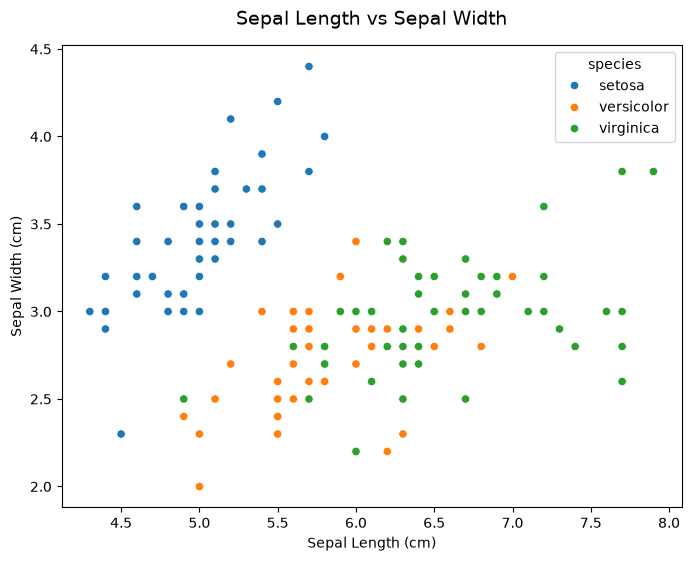

In [5]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='sepal length (cm)', y='sepal width (cm)', hue='species', data=df)
plt.title('Sepal Length vs Sepal Width', fontsize=14, pad=15)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.show()

### Chart 2: Pairplot of Features

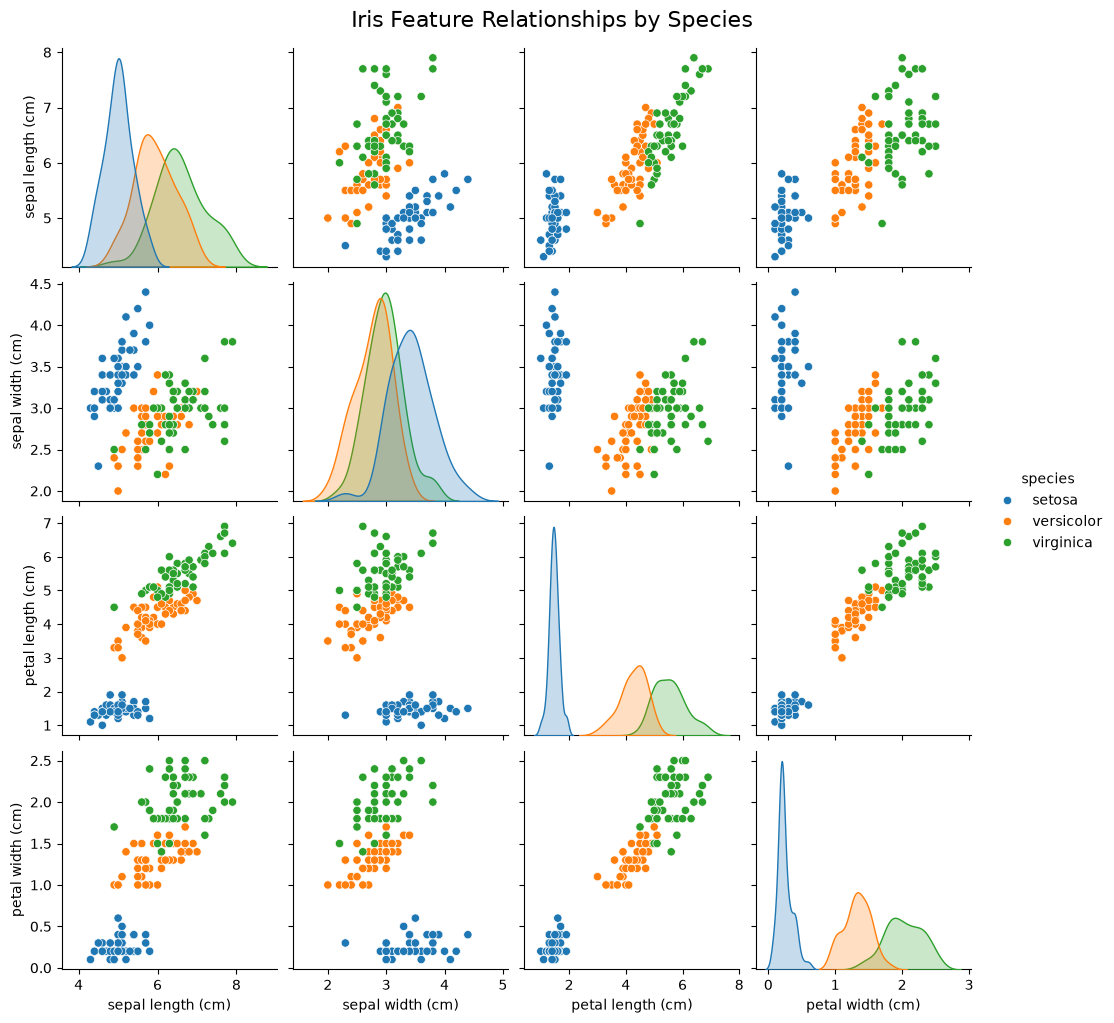

In [6]:
pairplot = sns.pairplot(df, hue='species')
pairplot.fig.suptitle('Iris Feature Relationships by Species', y=1.02, fontsize=16)
plt.show()

### Chart 3: Correlation Heatmap

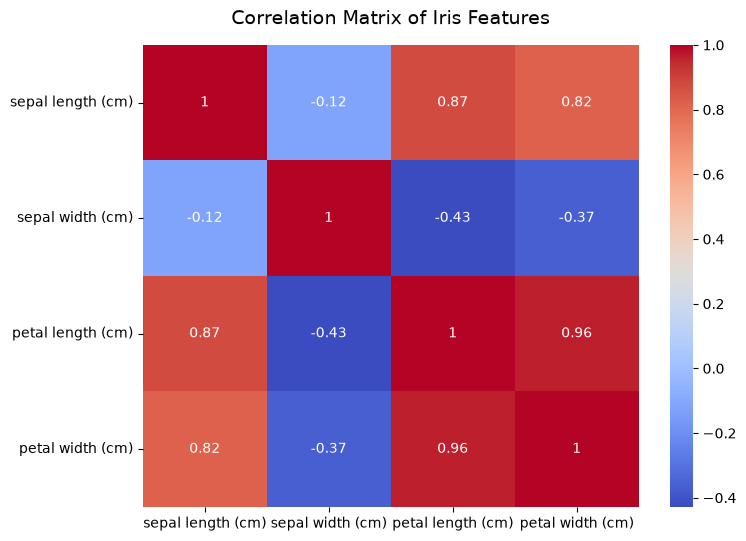

In [7]:
plt.figure(figsize=(8, 6))
corr_matrix = df.drop('species', axis=1).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Iris Features', fontsize=14, pad=15)
plt.show()

### Chart 4: Feature Distribution Boxplots

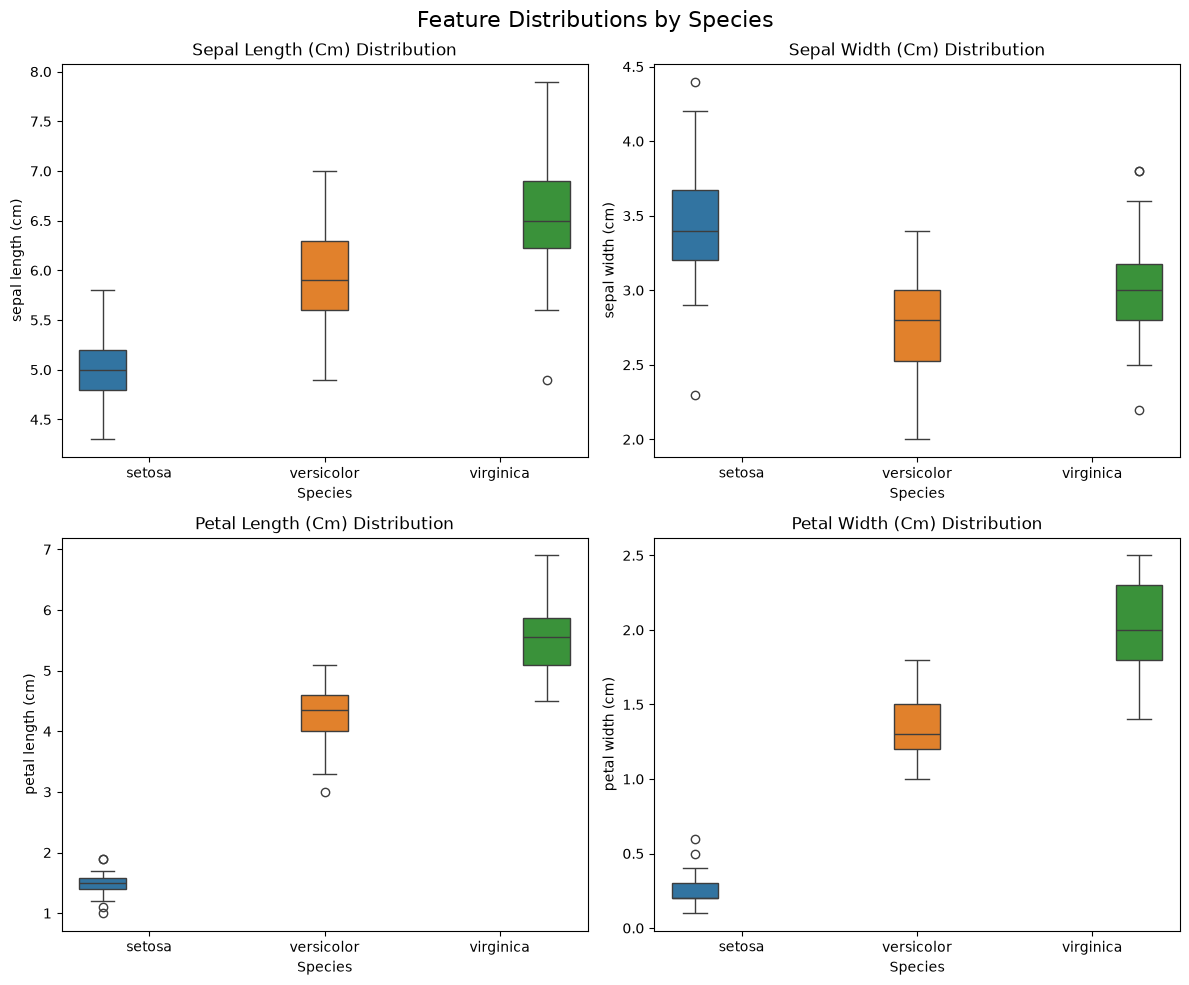

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
feature_cols = iris.feature_names
for idx, feature in enumerate(feature_cols):
    row = idx // 2
    col = idx % 2
    sns.boxplot(ax=axes[row, col], x='species', y=feature, data=df, hue='species', legend=False)
    axes[row, col].set_title(f'{feature.title()} Distribution', fontsize=12)
    axes[row, col].set_xlabel('Species')
    axes[row, col].set_ylabel(feature)

plt.suptitle('Feature Distributions by Species', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

## ✂️ Step 3: Splitting the Data (Study vs. Exam)
We split the flowers into:
- **Training Set (80%):** Flowers our AI uses to study.
- **Testing Set (20%):** Flowers kept secret for the final exam.

In [9]:
X = df.drop('species', axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Study Set: {X_train.shape[0]} flowers')
print(f'Exam Set: {X_test.shape[0]} flowers')

Study Set: 120 flowers
Exam Set: 30 flowers


## 🧠 Step 4 & 5: Training and Evaluating Model
We train **Logistic Regression** (boundary lines) matching our friend's code settings.

Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



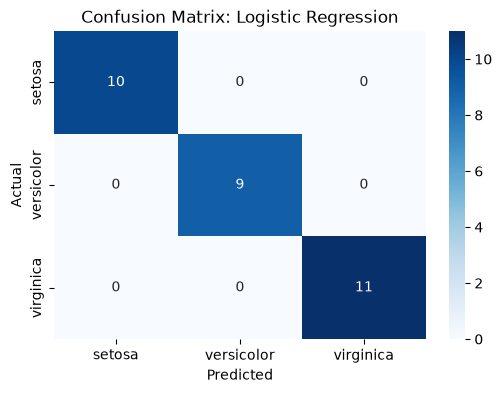

In [10]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Test predictions
y_pred = model.predict(X_test)

# Print Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy*100:.2f}%')

# Classification Report
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['setosa', 'versicolor', 'virginica'], yticklabels=['setosa', 'versicolor', 'virginica'])
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 🏆 Step 6: Predicting on Custom Inputs
Let's feed three new flower samples to the trained model!

In [11]:
custom_samples = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2],  # Expected: setosa
     [6.0, 2.9, 4.5, 1.5],  # Expected: versicolor
     [6.7, 3.0, 5.8, 2.2]], # Expected: virginica
    columns=X.columns
)

predictions = model.predict(custom_samples)
for i, pred_name in enumerate(predictions):
    print(f'  Sample {i+1} {list(custom_samples.iloc[i].values)}: {pred_name}')

  Sample 1 [np.float64(5.1), np.float64(3.5), np.float64(1.4), np.float64(0.2)]: setosa
  Sample 2 [np.float64(6.0), np.float64(2.9), np.float64(4.5), np.float64(1.5)]: versicolor
  Sample 3 [np.float64(6.7), np.float64(3.0), np.float64(5.8), np.float64(2.2)]: virginica
